# DZHAHIRA SHAFA

# 09011382227150

# **Leukemia Classification**

# Import Library

In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import matplotlib.cm as cm
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Layer, Flatten
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense
from tensorflow.keras.applications import VGG16, VGG19
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = '/content/drive/MyDrive/UAS AI'

**Data** **Generator**

In [ ]:
# Menetapkan ukuran batch dan ukuran gambar
batch_size = 32  # Ukuran batch yang digunakan untuk pelatihan dan validasi
img_size = 224   # Ukuran gambar yang akan diubah menjadi 224x224 piksel

# Inisialisasi ImageDataGenerator untuk augmentasi data
datagen = ImageDataGenerator(rescale=1/255.,  # Menormalisasi piksel gambar dari [0, 255] menjadi [0, 1]
                  rotation_range=20,          # Memutar gambar hingga 20 derajat secara acak
                  width_shift_range=0.2,      # Menggeser gambar secara horizontal hingga 20% dari lebar gambar
                  height_shift_range=0.2,     # Menggeser gambar secara vertikal hingga 20% dari tinggi gambar
                  shear_range=0.2,            # Menerapkan transformasi shear pada gambar (distorsi perspektif)
                  zoom_range=0.2,             # Memperbesar atau memperkecil gambar hingga 20%
                  horizontal_flip=True,       # Membalik gambar secara horizontal
                  fill_mode='nearest',        # Mengisi piksel kosong yang dihasilkan oleh augmentasi dengan nilai piksel terdekat
                  validation_split=0.15       # Membagi data menjadi 85% pelatihan dan 15% validasi
            )

# Generator untuk data pelatihan
train_generator = datagen.flow_from_directory('/content/drive/MyDrive/UAS AI/training', # Path ke folder data pelatihan
                target_size=(img_size, img_size),  # Ukuran gambar yang diinginkan (224x224 piksel)
                batch_size=batch_size,             # Ukuran batch (64 gambar per iterasi)
                shuffle=True,                      # Mengacak urutan gambar di setiap batch untuk pelatihan
                class_mode='categorical',          # Output berupa kelas kategori (untuk klasifikasi multi-kelas)
                subset='training'                  # Menggunakan subset data pelatihan dari total data yang ada
            )

# Generator untuk data validasi
validation_generator = datagen.flow_from_directory('/content/drive/MyDrive/UAS AI/testing',  # Path ke folder data pengujian/validasi
                target_size=(img_size, img_size),  # Ukuran gambar yang diinginkan (224x224 piksel)
                batch_size=batch_size,             # Ukuran batch yang sama dengan pelatihan
                shuffle=False,                     # Tidak mengacak urutan gambar dalam batch saat validasi
                class_mode='categorical',          # Output berupa kelas kategori
                subset='validation'                # Menggunakan subset data validasi dari total data yang ada
            )


Found 850 images belonging to 2 classes.
Found 30 images belonging to 2 classes.


Fungsi di atas bertujuan untuk menyiapkan data augmentation dan pembagian dataset menjadi subset pelatihan dan validasi menggunakan ImageDataGenerator dengan menggunakan model Convolutional Neural Networks (CNN).

# **ConvNet Model (Pretrained VGG-19)**

**Model Definition and Hyperparameter Settings**

In [ ]:
base_model = VGG19(include_top = False,
                   weights = 'imagenet',
                   input_shape = (img_size,img_size,3))

last = base_model.layers[-2].output
x = GlobalAveragePooling2D()(last)
x = Dense(512,'relu')(x)
x = Dense(2, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=x)

model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=0.0001),
              metrics=['accuracy'])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv4 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv4 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv4 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 20,288,066 (77.39 MB)

 Trainable params: 20,288,066 (77.39 MB)

 Non-trainable params: 0 (0.00 B)

Fungsi ini membangun dan mengkompilasi sebuah model CNN yang menggunakan VGG16 yang telah dilatih sebelumnya untuk ekstraksi fitur.

**Model Checkpoints**

In [ ]:
model_name = "model.keras"  # Change the extension to .keras
checkpoint = ModelCheckpoint(model_name,
                            monitor="val_loss",
                            mode="min",
                            save_best_only = True,
                            verbose=1)

earlystopping = EarlyStopping(monitor='val_loss',min_delta = 0, patience = 5, verbose = 1, restore_best_weights=True)

learning_rate_reduction = ReduceLROnPlateau(monitor='val_loss',
                                            patience=3,
                                            verbose=1,
                                            factor=0.2,
                                            min_lr=0.00000001)

Fungsi kode diatas:

check point : Fungsi ini berfungsi untuk menyimpan model selama pelatihan hanya jika model mengalami peningkatan kinerja (misalnya, lebih baik dalam hal validasi loss).

early stopping : Fungsi ini menghentikan pelatihan lebih awal jika model tidak menunjukkan perbaikan dalam beberapa epoch berturut-turut.

learning rate : untuk mengurangi learning rate jika model tidak mengalami peningkatan pada validasi loss dalam beberapa epoch.


**Model Training**

In [ ]:
history = model.fit(train_generator,
                    epochs=35,
                    validation_data=validation_generator,
                    callbacks=[checkpoint,learning_rate_reduction])

Epoch 1/35


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5792 - loss: 0.7003
Epoch 1: val_loss improved from inf to 0.60110, saving model to model.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.5804 - loss: 0.6990 - val_accuracy: 0.6667 - val_loss: 0.6011 - learning_rate: 1.0000e-04
Epoch 2/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - accuracy: 0.6690 - loss: 0.6096
Epoch 2: val_loss did not improve from 0.60110
27/27 ━━━━━━━━━━━━━━━━━━━━ 23s 701ms/step - accuracy: 0.6707 - loss: 0.6079 - val_accuracy: 0.7000 - val_loss: 0.6938 - learning_rate: 1.0000e-04
Epoch 3/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - accuracy: 0.7415 - loss: 0.5323
Epoch 3: val_loss did not improve from 0.60110
27/27 ━━━━━━━━━━━━━━━━━━━━ 40s 697ms/step - accuracy: 0.7416 - loss: 0.5322 - val_accuracy: 0.5667 - val_loss: 0.6349 - learning_rate: 1.0000e-04
Epoch 4/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - accuracy: 0.7806 - loss: 0.5018
Epoch 4: val_loss did not improve from 0.60110

Epoch 4: ReduceL

**Learning Curves**

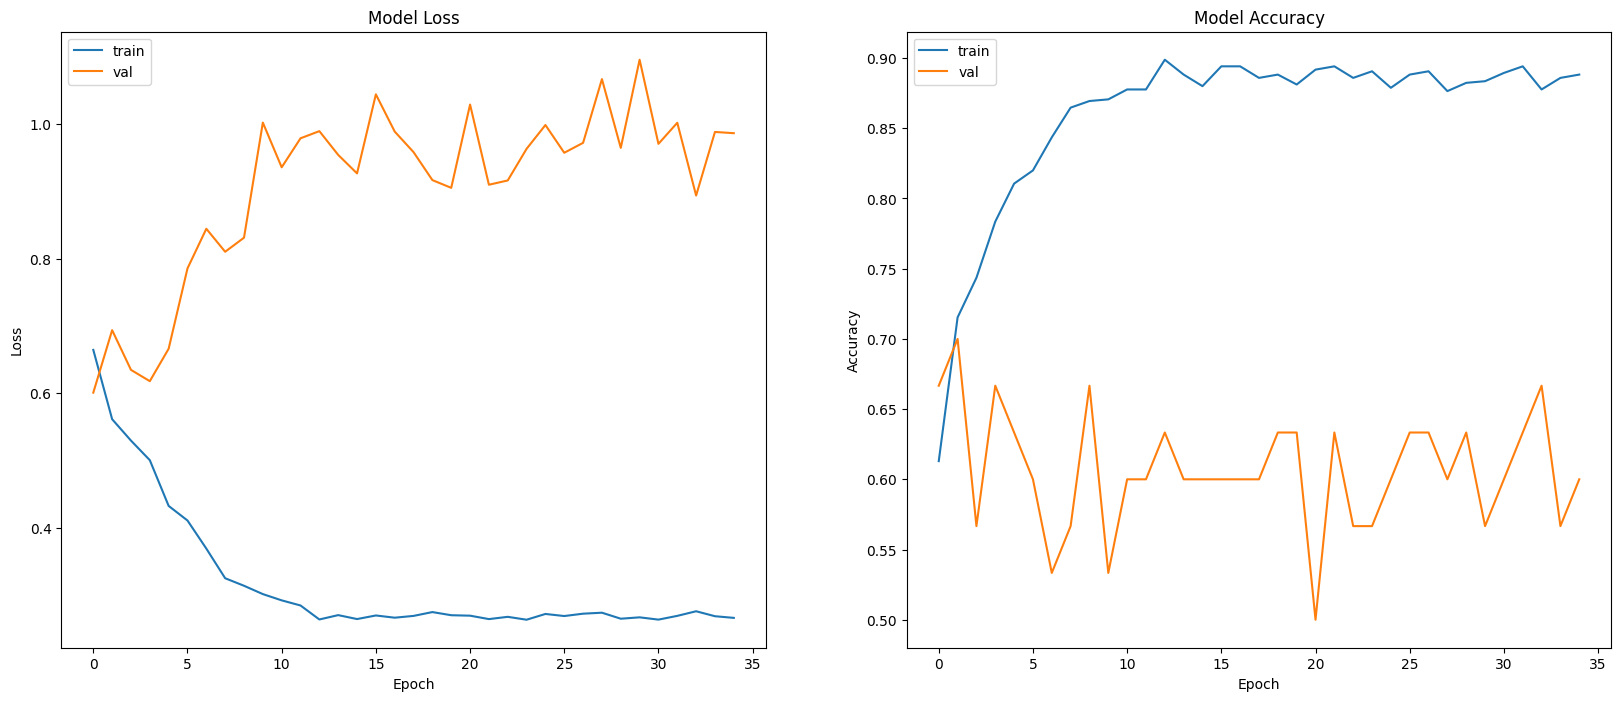

In [ ]:
# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(20, 8))

# Plot the loss in the first subplot
axs[0].plot(history.history['loss'], label='train')
axs[0].plot(history.history['val_loss'], label='val')
axs[0].set_title('Model Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend(loc='upper left')

# Plot the accuracy in the second subplot
axs[1].plot(history.history['accuracy'], label='train')
axs[1].plot(history.history['val_accuracy'], label='val')
axs[1].set_title('Model Accuracy')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')
axs[1].legend(loc='upper left')

# Display the plots
plt.show()

**Model Evalutation**

In [ ]:
from sklearn.metrics import classification_report

y_val = validation_generator.classes
y_pred = model.predict(validation_generator)
y_pred = np.argmax(y_pred,axis=1)

print(classification_report(y_val,y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
              precision    recall  f1-score   support

           0       0.75      0.40      0.52        15
           1       0.59      0.87      0.70        15

    accuracy                           0.63        30
   macro avg       0.67      0.63      0.61        30
weighted avg       0.67      0.63      0.61        30



menampilkan hasil evaluasi klasifikasi untuk nilai 0 normal dan 1 leukemia

In [ ]:
class_indices = validation_generator.class_indices
indices = {v:k for k,v in class_indices.items()}

filenames = validation_generator.filenames

val_df = pd.DataFrame()
val_df['filename'] = filenames
val_df['actual'] = y_val
val_df['predicted'] = y_pred
val_df['actual'] = val_df['actual'].apply(lambda x: indices[x])
val_df['predicted'] = val_df['predicted'].apply(lambda x: indices[x])
val_df.loc[val_df['actual']==val_df['predicted'],'Same'] = True
val_df.loc[val_df['actual']!=val_df['predicted'],'Same'] = False
val_df.head(10)

,filename,actual,predicted,Same
0,all/UID_16_15_1_all.bmp,all,hem,False
1,all/UID_16_1_1_all.bmp,all,all,True
2,all/UID_16_1_2_all.bmp,all,all,True
3,all/UID_16_1_3_all.bmp,all,hem,False
4,all/UID_16_2_1_all.bmp,all,hem,False
5,all/UID_16_2_2_all.bmp,all,hem,False
6,all/UID_16_3_1_all.bmp,all,hem,False
7,all/UID_16_3_2_all.bmp,all,hem,False
8,all/UID_16_3_3_all.bmp,all,hem,False
9,all/UID_16_3_4_all.bmp,all,all,True


In [ ]:
filenames = validation_generator.filenames

In [ ]:
val_df = pd.DataFrame()
val_df['filename'] = filenames
val_df['actual'] = y_val
val_df['predicted'] = y_pred
val_df['actual'] = val_df['actual'].apply(lambda x: indices[x])
val_df['predicted'] = val_df['predicted'].apply(lambda x: indices[x])
val_df.loc[val_df['actual']==val_df['predicted'],'Same'] = True
val_df.loc[val_df['actual']!=val_df['predicted'],'Same'] = False
val_df.head(10)

,filename,actual,predicted,Same
0,all/UID_16_15_1_all.bmp,all,hem,False
1,all/UID_16_1_1_all.bmp,all,all,True
2,all/UID_16_1_2_all.bmp,all,all,True
3,all/UID_16_1_3_all.bmp,all,hem,False
4,all/UID_16_2_1_all.bmp,all,hem,False
5,all/UID_16_2_2_all.bmp,all,hem,False
6,all/UID_16_3_1_all.bmp,all,hem,False
7,all/UID_16_3_2_all.bmp,all,hem,False
8,all/UID_16_3_3_all.bmp,all,hem,False
9,all/UID_16_3_4_all.bmp,all,all,True


# **Grad-CAM**

Image Visualization

In [ ]:
val_df = val_df.sample(frac=1).reset_index(drop=True)

def readImage(path):
    img = load_img(path,color_mode='rgb',target_size=(img_size,img_size))
    img = img_to_array(img)
    img = img/255.

    return img


def display_images(temp_df):
    temp_df = temp_df.reset_index(drop=True)
    plt.figure(figsize=(20, 20))
    n = 0
    # Loop up to the smaller of 15 or the length of temp_df
    for i in range(min(15, len(temp_df))):
        n += 1
        plt.subplot(5, 5, n)
        plt.subplots_adjust(hspace=0.5, wspace=0.3)
        image = readImage(path=f"/content/drive/MyDrive/UAS AI/testing/{temp_df.filename[i]}")
        plt.imshow(image)
        plt.title(f'A: {temp_df.actual[i]} P: {temp_df.predicted[i]}')

# Correctly Classified

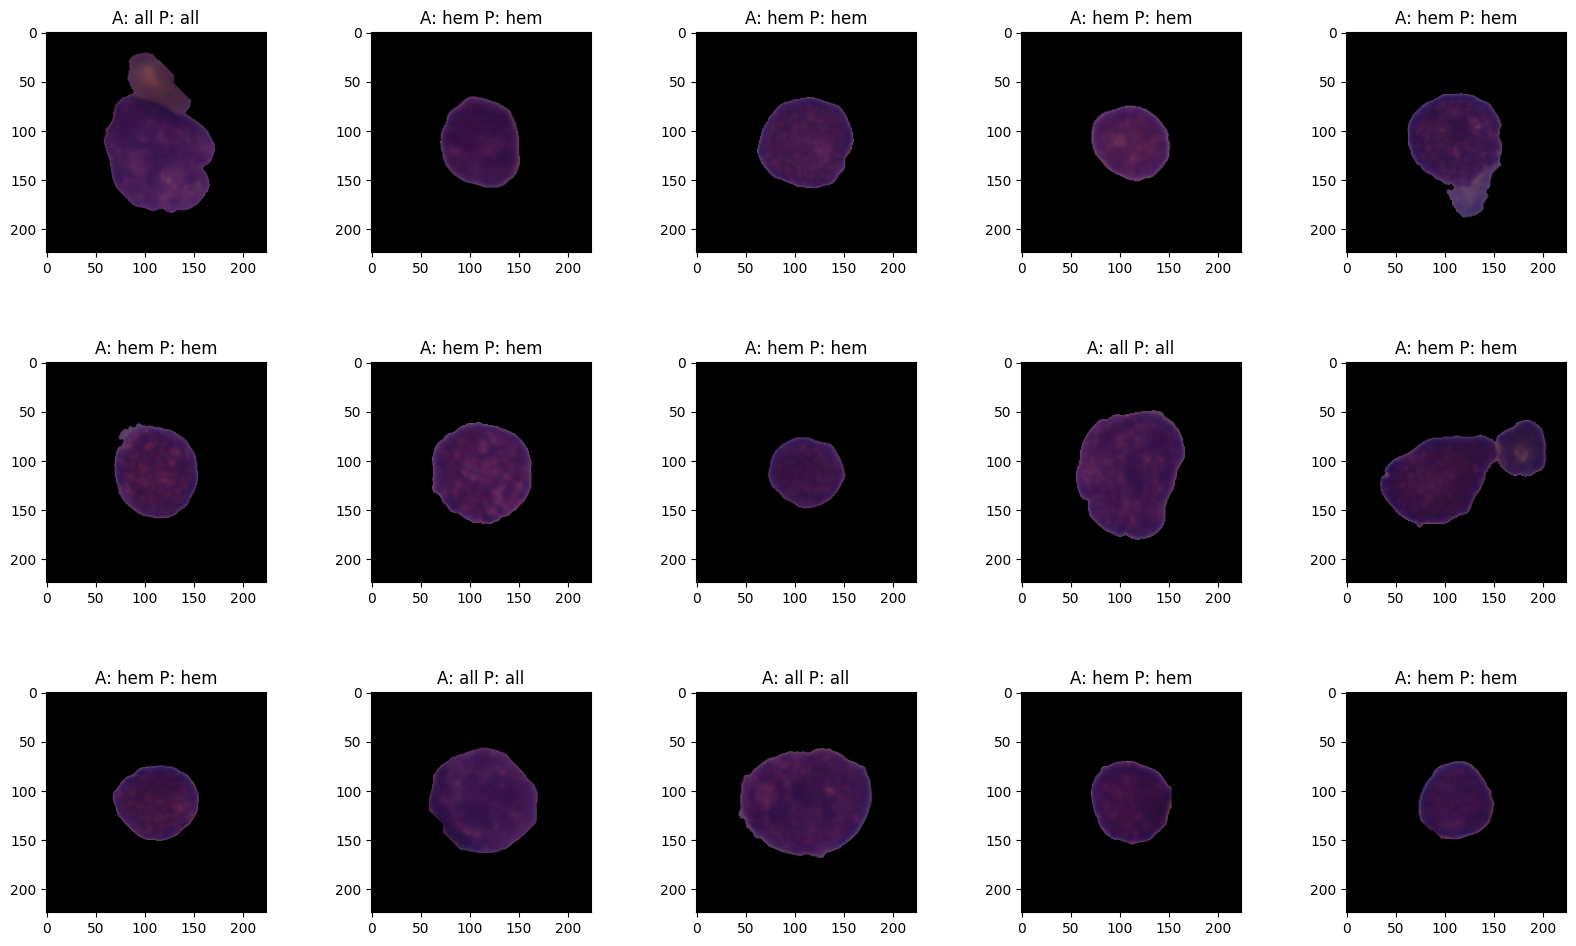

In [ ]:
display_images(val_df[val_df['Same']==True])

**Misclassified**

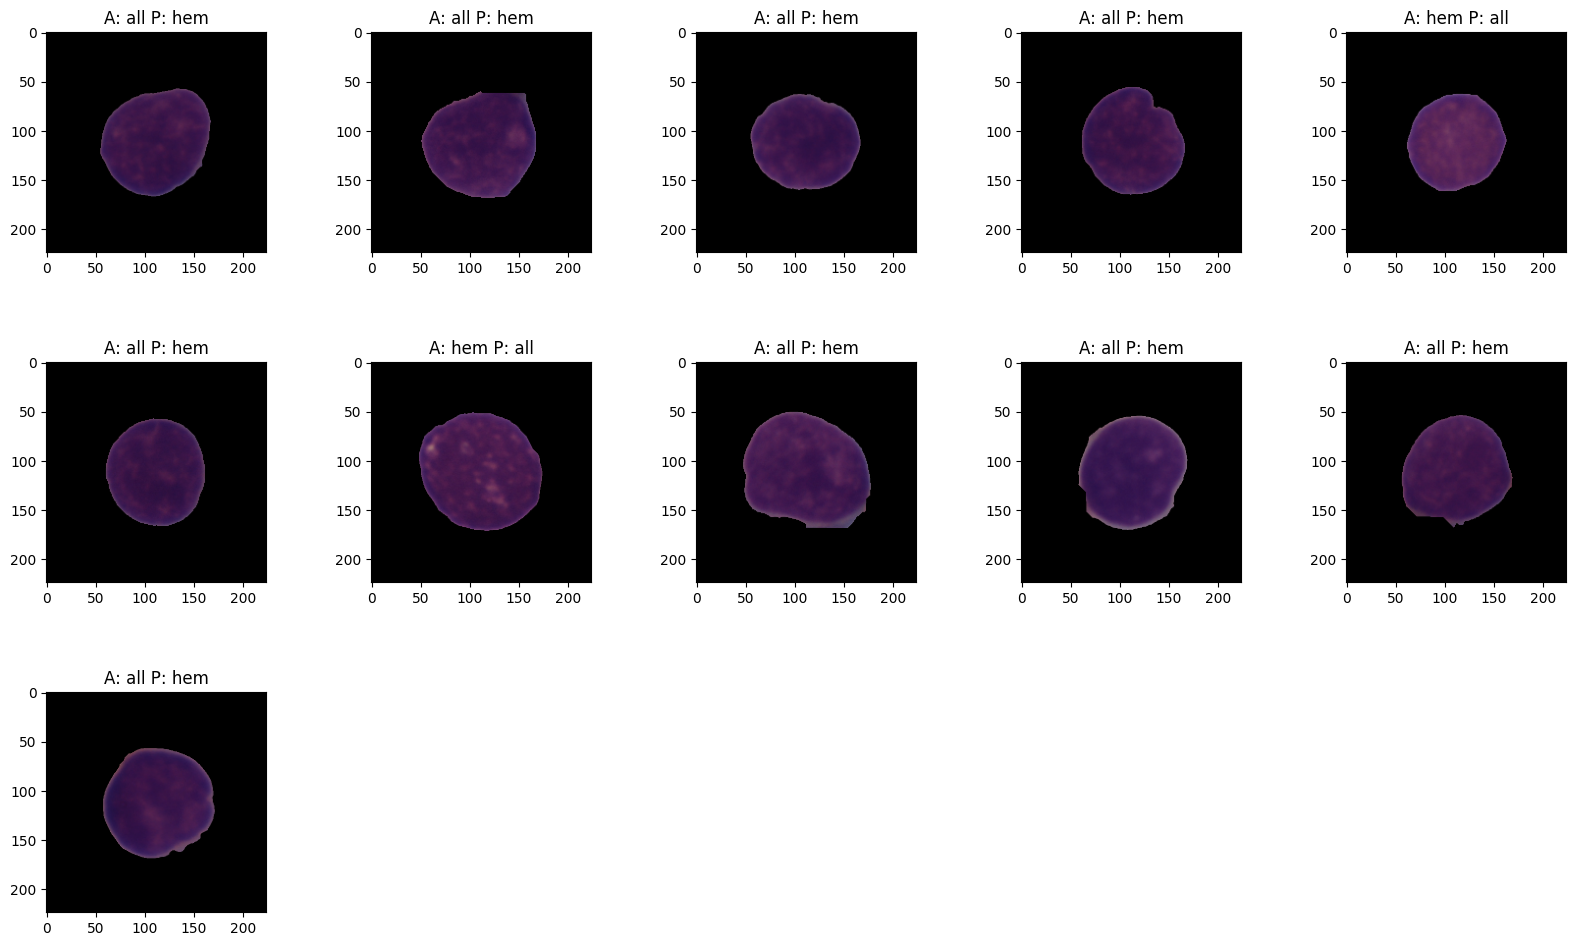

In [ ]:
display_images(val_df[val_df['Same']!=True])

**Grad-CAM Computation**

In [ ]:
def make_gradcam_heatmap(img_array, model, pred_index=None):

    grad_model = Model(inputs=model.inputs, outputs=[model.layers[-4].output, model.output])

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy(), preds

In [ ]:
import matplotlib.cm as cm

val_df

,filename,actual,predicted,Same
0,all/UID_16_6_2_all.bmp,all,all,True
1,hem/UID_H10_12_1_hem.bmp,hem,hem,True
2,hem/UID_H10_10_1_hem.bmp,hem,hem,True
3,hem/UID_H10_11_1_hem.bmp,hem,hem,True
4,hem/UID_H10_13_1_hem.bmp,hem,hem,True
5,hem/UID_H10_14_1_hem.bmp,hem,hem,True
6,hem/UID_H10_16_2_hem.bmp,hem,hem,True
7,hem/UID_H10_10_3_hem.bmp,hem,hem,True
8,all/UID_16_3_2_all.bmp,all,hem,False
9,all/UID_16_1_2_all.bmp,all,all,True


**Grad-CAM Projection**

In [ ]:
def gradCAMImage(image):
    path = f"/content/drive/MyDrive/UAS AI/testing/{image}"
    img = readImage(path)
    img = np.expand_dims(img,axis=0)
    heatmap,preds = make_gradcam_heatmap(img,model)

    img = load_img(path)
    img = img_to_array(img)
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = cm.get_cmap("jet")

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * 0.8 + img
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)

    return superimposed_img

# **Results**

In [ ]:
def gradcam_of_images(correct_class):
    grad_images = []
    title = []
    temp_df = val_df[val_df['Same']==correct_class]
    temp_df = temp_df.reset_index(drop=True)

    # Get the number of rows in temp_df
    num_rows = len(temp_df)

    # Iterate through the available rows, up to a maximum of 15
    for i in range(min(num_rows, 15)):
        image = temp_df.filename[i]
        grad_image = gradCAMImage(image)
        grad_images.append(grad_image)
        title.append(f"A: {temp_df.actual[i]} P: {temp_df.predicted[i]}")

    return grad_images, title

correctly_classified, c_titles = gradcam_of_images(correct_class=True)
misclassified, m_titles = gradcam_of_images(correct_class=False)

<ipython-input-18-df25021f7067>:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  jet = cm.get_cmap("jet")


In [ ]:
def display_heatmaps(classified_images, titles):
    plt.figure(figsize=(20, 20))
    n = 0
    num_images = len(classified_images) # Get the actual number of images
    for i in range(min(num_images, 15)): # Iterate up to the number of images or 15, whichever is smaller
        n += 1
        plt.subplot(5, 5, n)
        plt.subplots_adjust(hspace=0.5, wspace=0.3)
        plt.imshow(classified_images[i])
        plt.title(titles[i])
    plt.show()

**Grad-CAM: Correctly Classified**

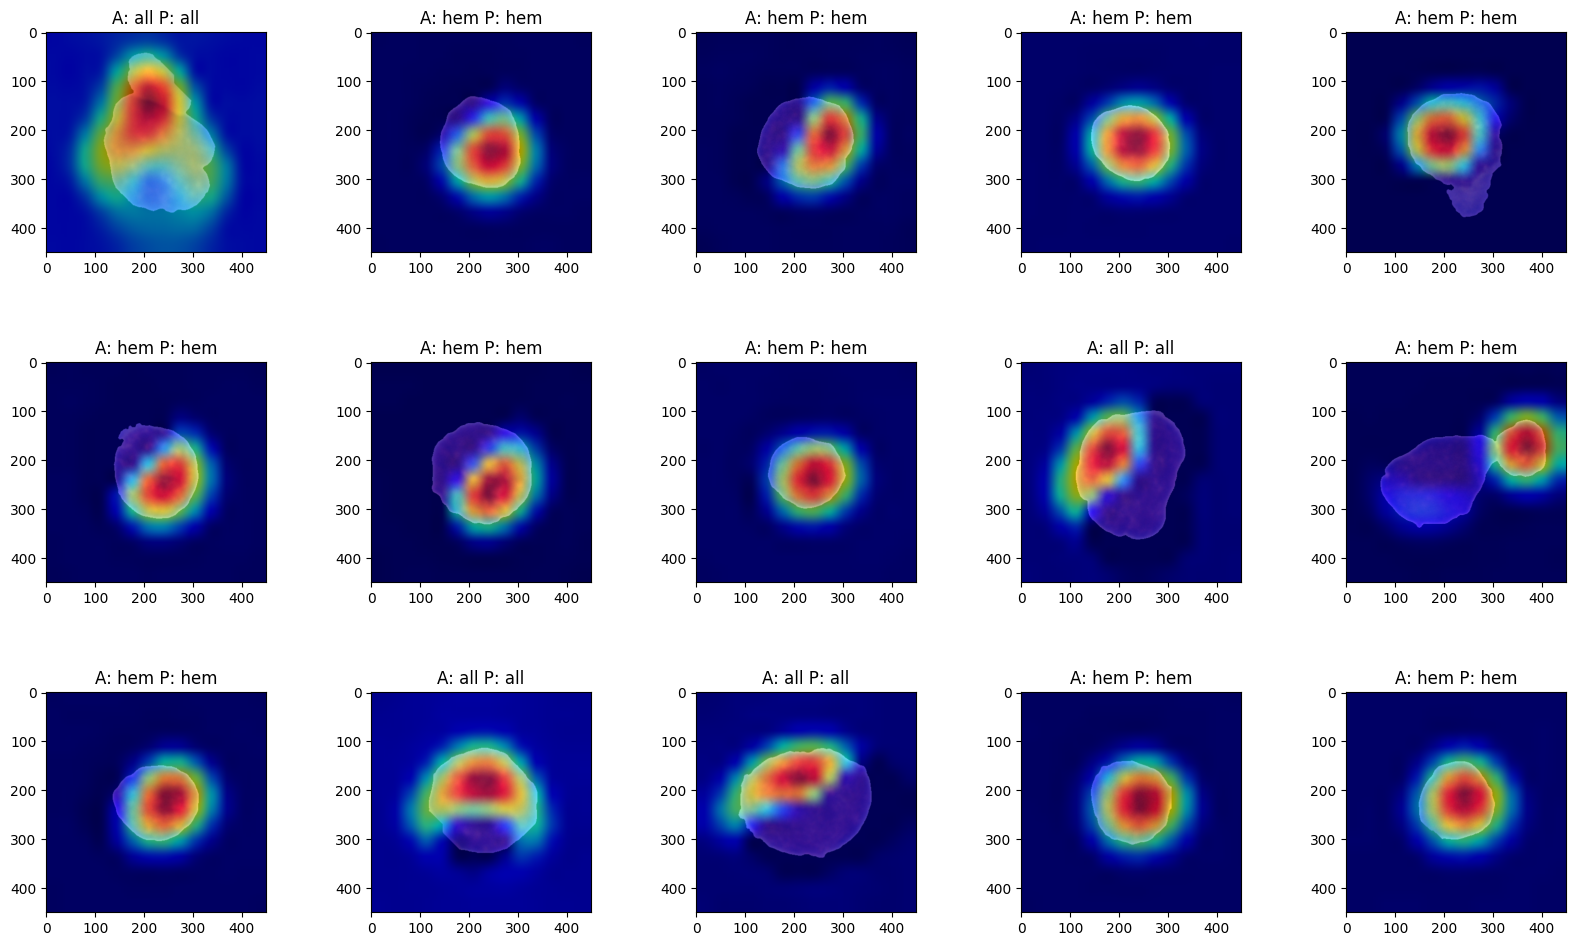

In [ ]:
display_heatmaps(correctly_classified,c_titles)

**Grad-CAM: Incorrectly Classified**

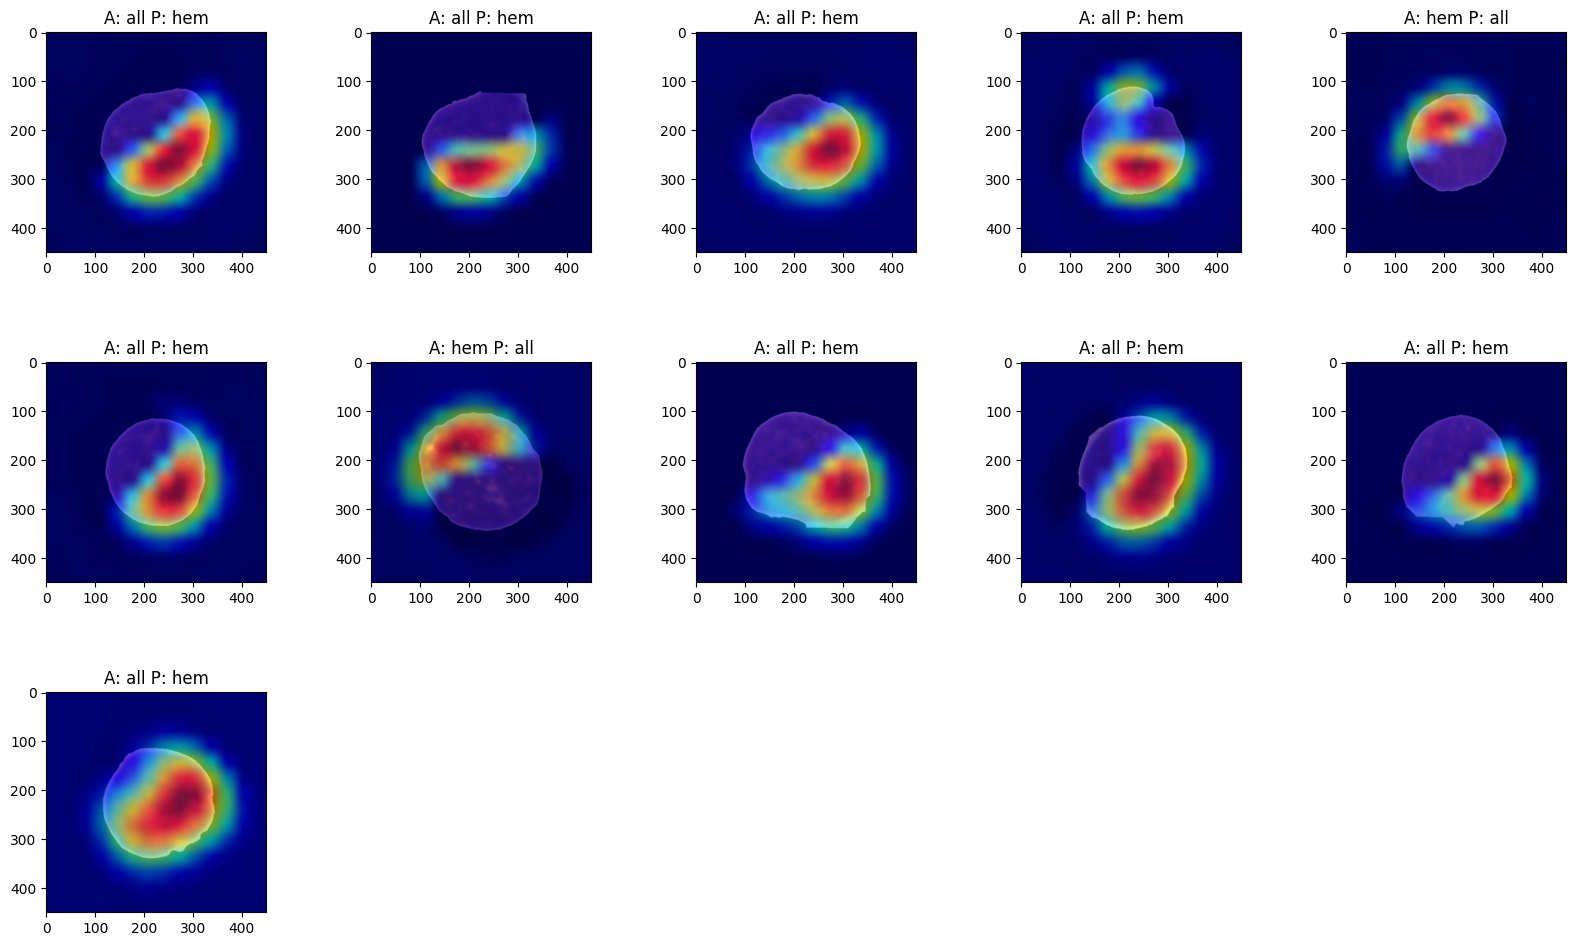

In [ ]:
display_heatmaps(misclassified,m_titles)

Summary :



Data Leukemia ini asli dari kaggle sebanyak 15.135 dari 118 pasien. Dan data di potong menjadi 1200 data, 80% data train (1000) dan 20% data test (200)


dengan memasukkan batch size 32 dengan epoch 35 untuk VGG19 mendapatkan akurasi sekitar 0.87 dengan grafik overfitting. gradcam tidak keluar dari sell yang di predict. dan memiliki 11 misclassified.



```
              precision    recall  f1-score   support

           0       0.75      0.40      0.52        15
           1       0.59      0.87      0.70        15

    accuracy                           0.63        30
   macro avg       0.67      0.63      0.61        30
weighted avg       0.67      0.63      0.61        30

```

kemudian dengan memasukkan batch size 32 dengan epoch 25 untuk VGG16 mendapatkan akurasi sekitar 0.91 dengan grafik overfitting. gradcam tidak keluar dari sell yang di predict. dan memiliki 14 misclassified.



```
              precision    recall  f1-score   support

           0       0.62      0.42      0.52        15
           1       0.50      0.67      0.70        15

    accuracy                           0.52        30
   macro avg       0.50      0.53      0.51        30
weighted avg       0.50      0.53      0.51        30

```



Kemudian saya mengganti batch size dengan 64 dengan epoch 10 juga mendapatkan hasil akurasi 0.85 dengan hasil overfitting. tetapi memiliki misclassified gradcam sebanyak 12. tetapi untuk area gradcam yang panas lebih tidak terlihat jelas, dan ada yang keluar dari cell


```
 precision    recall  f1-score   support

           0       0.64      0.47      0.54        15
           1       0.58      0.73      0.65        15

    accuracy                           0.60        30
   macro avg       0.61      0.60      0.59        30
weighted avg       0.61      0.60      0.59        30
```




untuk batch size 128 epoch 10 memiliki akurasi 0.82 memiliki 11 misclassified pada gradcam. grafik mengalami overfitting. dan untuk area gradcam yang panas lebih tidak terlihat jelas di banding batch size 32 dan 64

```
             precision    recall  f1-score   support

           0       0.64      0.60      0.62        15
           1       0.62      0.67      0.65        15

    accuracy                           0.63        30
   macro avg       0.63      0.63      0.63        30
weighted avg       0.63      0.63      0.63        30
```









